# Building a Convolutional Neural Network (CNN) 
# for Fashion-MNIST with PyTorch

- Master Applied AI - Amsterdam University of Applied Sciences
- Bootcamp Computer Vision - Michiel Bontenbal 28 aug 2025


Based on the book by Laurence Moroney: "AI and ML for Coders in PyTorch"
https://learning-oreilly-com.rps.hva.nl/library/view/ai-and-ml/9781098199166/ 

Beschikbaar via de HvA bibliotheek:
https://lib.hva.nl/permalink/31UKB_UAM2_INST/ooc2dr/alma9939149327405132

Tutorials:
- https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial
- https://www.geeksforgeeks.org/applying-convolutional-neural-network-on-mnist-dataset/ 

In [45]:
 # imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

print(torch.__version__)

2.8.0


In [46]:
import platform
print(platform.python_version())

3.13.7


In [47]:
# Load and transform the dataset
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [48]:
# Inspect the size of the datasets
len(train_dataset), len(test_dataset)

(60000, 10000)

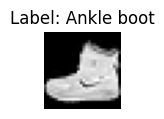

Image shape: (28, 28)
Label: 9 (Ankle boot)


In [49]:
# Define the class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Get the first image and label
image, label = train_dataset[0]

# Convert tensor to numpy array and reshape
image_np = image.squeeze().numpy()  # Remove the channel dimension and convert to numpy

# Create the plot
plt.figure(figsize=(1, 1))
plt.imshow(image_np, cmap='gray')
plt.title(f'Label: {class_names[label]}')
plt.axis('off')
plt.show()

print(f'Image shape: {image_np.shape}')
print(f'Label: {label} ({class_names[label]})')

## V1

In [50]:
# # Create model using nn.Sequential 
# model = nn.Sequential(
#     nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
#     nn.ReLU(),
#     nn.MaxPool2d(kernel_size=2, stride=2),  # Output: [batch, 32, 14, 14]
#     nn.Flatten(),
#     nn.Linear(32 * 14 * 14, 128),  # Adjusted input size due to Conv and Pool layers
#     nn.ReLU(),
#     nn.Linear(128, 10),
# )

## V2

Increased the number of filters in the first Conv2d layer to 64.
Added a second Conv2d layer with 128 filters.
Adjusted the Linear layer input size to match the new output dimensions after the pooling layers.
Increased the size of the hidden layer in the Linear layer to 256.

In [51]:
# Create model using nn.Sequential 
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1),  # Increased out_channels
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: [batch, 64, 14, 14]
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),  # Added another Conv2D layer
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: [batch, 128, 7, 7]
    nn.Flatten(),
    nn.Linear(128 * 7 * 7, 256),  # Adjusted input size and increased hidden layer size
    nn.ReLU(),
    nn.Linear(256, 10),  # Output layer remains the same
)

In [52]:
# Define loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [53]:
# Lists to store metrics
epoch_losses = []
epoch_accuracies = []

# Training loop
batch_size = 128
learning_rate = 0.001

epochs = 5

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    size = len(train_loader.dataset)
    model.train()
    epoch_loss = 0.0
    correct = 0
    
    for batch, (X, y) in enumerate(train_loader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_function(pred, y)
        
        # Calculate accuracy
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        
        # Accumulate loss for epoch
        epoch_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")
    
    # Calculate epoch metrics
    avg_loss = epoch_loss / len(train_loader)
    accuracy = 100 * correct / size
    epoch_losses.append(avg_loss)
    epoch_accuracies.append(accuracy)
    
    print(f"Epoch {t+1} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

print("Done!")


Epoch 1
-------------------------------
loss: 2.308307 [    0/60000]
loss: 0.606295 [12800/60000]
loss: 0.390712 [25600/60000]
loss: 0.400259 [38400/60000]
loss: 0.244889 [51200/60000]
Epoch 1 - Loss: 0.4424, Accuracy: 83.90%
Epoch 2
-------------------------------
loss: 0.203675 [    0/60000]
loss: 0.179597 [12800/60000]
loss: 0.292898 [25600/60000]
loss: 0.180696 [38400/60000]
loss: 0.342043 [51200/60000]
Epoch 2 - Loss: 0.2751, Accuracy: 90.06%
Epoch 3
-------------------------------
loss: 0.292492 [    0/60000]
loss: 0.243008 [12800/60000]
loss: 0.258488 [25600/60000]
loss: 0.213784 [38400/60000]
loss: 0.216829 [51200/60000]
Epoch 3 - Loss: 0.2306, Accuracy: 91.49%
Epoch 4
-------------------------------
loss: 0.272363 [    0/60000]
loss: 0.113614 [12800/60000]
loss: 0.305299 [25600/60000]
loss: 0.205573 [38400/60000]
loss: 0.135253 [51200/60000]
Epoch 4 - Loss: 0.1991, Accuracy: 92.72%
Epoch 5
-------------------------------
loss: 0.200352 [    0/60000]
loss: 0.196363 [12800/60000

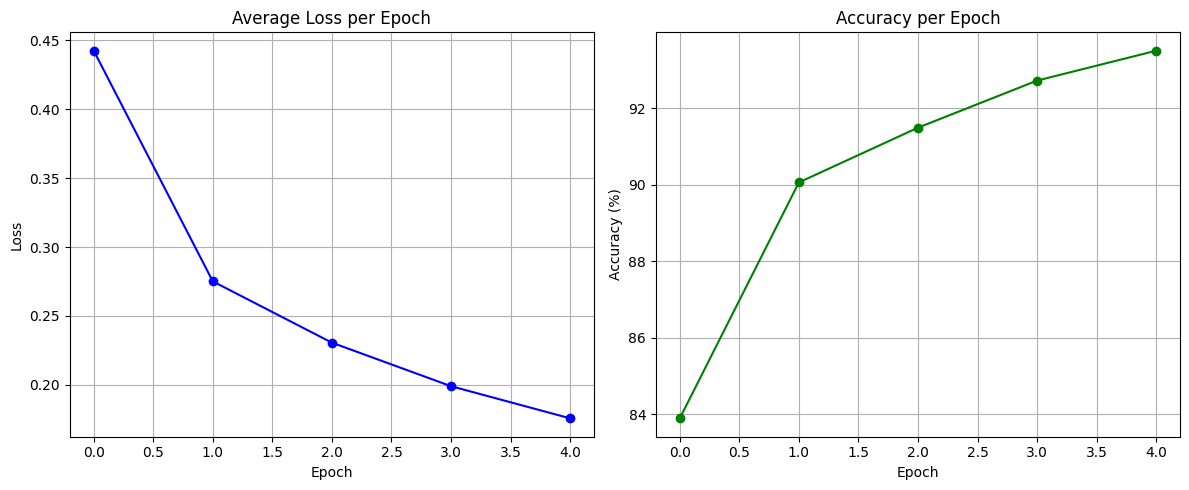

In [54]:

# Create the plots
plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epoch_losses, marker='o', color='b')
plt.title('Average Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epoch_accuracies, marker='o', color='g')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

## Exercises

### Exercise 0
Run the script and ensure it works correctly. Write down the accuracy.

Loss: 0.2309, Accuracy: 91.54%

### Exercise 2:
Adjust the parameters.
Write down the new accuracy.

Epoch 3 - Loss: 0.2112, Accuracy: 92.16%

### Exercise 3:
Adjust the hyperparameters of the model.
Write down the new accuracy.


Epoch 5 - Loss: 0.1758, Accuracy: 93.50%

## Reflectie vragen

### Reflectie
Deze vragen gaan over het begrip van het model wat je hebt gebruikt. 
Beantwoord de volgende vragen in je eigen woorden. 

#### 1. Welke lagen heb je gebruikt in je model?

Kernel convultion layers, pooling layers voor dimensionaliteit reducen en lineare lagen die fully connected zijn.

#### 2. Beschrijf kort hoe de Conv2D laag werkt (in je eigen woorden)

De conv2D slide de kernel als klein filter over de grotere image met een stride (stap grote) en extract features of kleine onderdelen die herkenbaar zijn.

#### 3. Waarom gebruik je een pooling laag?

De pooling layer verminderd de dimensionaliteit door met behulp van een berekening de waardes te verkleine. een matrix van 4*4 wordt bijvoorbeeld 2*2 waardoor de dimensies kleiner zijn en makkelijk om mee te werken.

Max pooling pakt vervolgens de hoogste nummers uit de 4*4 om voor de 2*2 pool mee te nemen. En average pooling pakt het gemiddelde.

"The pooling layer reduces the spatial dimensions (height and width) of the input feature maps while retaining the most important information."

#### 4. Wat doet de linear laag?

De lineare laag aka de fully connected layer mapped de input features naar de gewenste output met een lineare transformatie. Het wordt meestal gebruikt om de dimensionaliteit te vminderen naar het benodige aantal voor de output